In [76]:
import sys
sys.path.append("..")
import os
import pandas as pd
import pickle
from tqdm import tqdm
import numpy as np

In [77]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Linguistic Confidence",
    "dist_semantic_uncertainty": "Dist. Semantic Uncertainty",
    "dist_lnll": "Dist. Token Probability"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "trivia_qa": "TriviaQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [78]:
results_dir = "/hdd/ivny/results"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)


all_records = []
for leaf_dir in tqdm(leaf_dirs):
    _, _, _, _, dataset_name, estimation_method, _, model_name, _ = leaf_dir.split("/")
    with open(os.path.join(leaf_dir, "graded_outputs_0.pkl"), "rb") as f:
        outputs = pickle.load(f)
    conf_dists = outputs.extracted_confidences[0]
    std = np.array([d.sigma for d in conf_dists])
    
    df_dict = {
        "Dataset": dataset_map[dataset_name],
        "Est. Method": methods_names[estimation_method],
        "Model": model_name_map[model_name],
        "Std": std
    }
    all_records.append(df_dict)
full_df = pd.DataFrame(all_records)
full_df

100%|██████████| 54/54 [00:02<00:00, 21.19it/s]


,Dataset,Est. Method,Model,Std
0,MMLU,Dist. Linguistic Confidence,Llama-3.1-8B-Inst.,"[0.1681137181262202, 0.2140031152421229, 0.220..."
1,MMLU,Dist. Linguistic Confidence,Llama-3-8B-Inst.,"[0.11004241606459454, 0.11567002876958038, 0.0..."
2,MMLU,Dist. Linguistic Confidence,Qwen2.5-7B-Inst.,"[0.1440925628430096, 0.19109508976772094, 0.09..."
3,MMLU,Dist. Linguistic Confidence,Qwen3-8B-Inst.,"[0.1415061836104698, 0.20271052157092279, 0.15..."
4,MMLU,Dist. Linguistic Confidence,Mistral-7B-Inst.,"[0.05674112754920858, 0.20609598626745634, 0.1..."
5,MMLU,Dist. Linguistic Confidence,GPT-OSS-20B,"[0.07816222446510417, 0.24217899716256702, 0.2..."
6,MMLU,Dist. Semantic Uncertainty,Llama-3.1-8B-Inst.,"[0.0001, 0.07922120928135343, 0.12631706139710..."
7,MMLU,Dist. Semantic Uncertainty,Llama-3-8B-Inst.,"[0.058103356185335804, 0.10384603988597738, 0...."
8,MMLU,Dist. Semantic Uncertainty,Qwen2.5-7B-Inst.,"[0.045825756949558406, 0.0001, 0.0001, 0.0001,..."
9,MMLU,Dist. Semantic Uncertainty,Qwen3-8B-Inst.,"[0.0001, 0.0001, 0.0001, 0.10637668917577761, ..."


In [79]:
"""
Est. Method
Dist. Ling. Conf.      [0.1681137181262202, 0.2140031152421229, 0.220...
Dist. Semantic Unc.    [0.0001, 0.07922120928135343, 0.12631706139710...
Dist. Token Prob       [0.0003534046065621454, 0.007680334007716372, ...
Name: Std, dtype: object
"""

full_df.drop(columns=["Dataset", "Model"], errors="ignore").groupby(["Est. Method"])["Std"].apply(lambda x: list(np.concatenate(x.values)))

Est. Method
Dist. Linguistic Confidence    [0.1681137181262202, 0.2140031152421229, 0.220...
Dist. Semantic Uncertainty     [0.0001, 0.07922120928135343, 0.12631706139710...
Dist. Token Probability        [0.0003534046065621454, 0.007680334007716372, ...
Name: Std, dtype: object

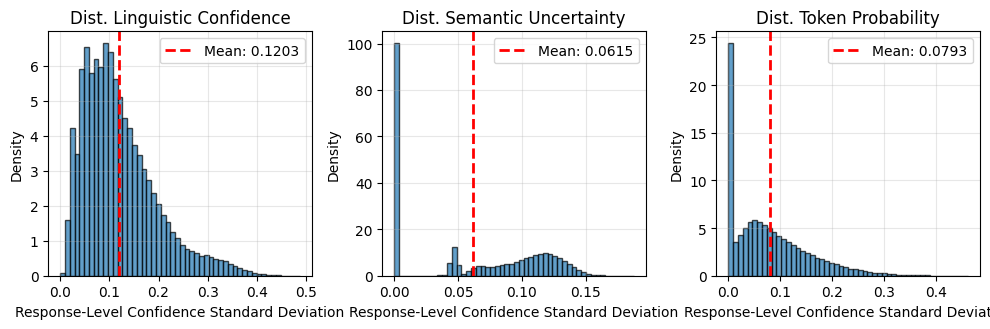

In [80]:
import matplotlib.pyplot as plt

# Group data by estimation method
grouped_std = full_df.drop(columns=["Dataset", "Model"], errors="ignore").groupby(["Est. Method"])["Std"].apply(lambda x: list(np.concatenate(x.values)))

# Create 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))

# Plot density for each estimation method
for idx, (method, std_values) in enumerate(grouped_std.items()):
    axes[idx].hist(std_values, bins=50, alpha=0.7, edgecolor='black', density=True)
    
    # Calculate and plot mean
    mean_std = np.mean(std_values)
    axes[idx].axvline(mean_std, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_std:.4f}')
    
    axes[idx].set_xlabel('Response-Level Confidence Standard Deviation')
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(method)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

# fig.suptitle('Response-Level Confidence Standard Deviation Distributions', fontsize=14)
plt.tight_layout()
plt.savefig("response_level_confidence_std_distributions.pdf", bbox_inches='tight', dpi=300)